In [2]:
# y = ax + b
# Coefficient(hệ số) (a)
#   (b)
# train data: 80%; test data: 20%

import pandas as pd;

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import  LinearRegression, LogisticRegression

simpleRegresDf = pd.read_csv('data_simple_reg.csv')
simpleRegresDf.head()

,TT,Quang_Cao,Tiep_Thi,Online,Doanh_So
0,0,12.0,5.993562,3.730133,79.732757
1,1,13.0,6.741511,3.006753,71.677897
2,2,41.0,15.405956,2.987338,175.177829
3,3,78.0,28.294987,6.934639,323.246340
4,4,11.0,6.663944,1.633811,81.594181


In [74]:
simpleRegresDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TT         4572 non-null   int64  
 1   Quang_Cao  4562 non-null   float64
 2   Tiep_Thi   4568 non-null   float64
 3   Online     4566 non-null   float64
 4   Doanh_So   4566 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 178.7 KB


In [75]:
simpleRegresDf.describe()

,TT,Quang_Cao,Tiep_Thi,Online,Doanh_So
count,4572.000000,4562.000000,4568.000000,4566.000000,4566.000000
mean,2285.500000,49.576502,16.931319,3.817391,217.466602
std,1319.967045,26.267450,9.637029,2.231164,93.133092
min,0.000000,1.000000,0.000684,0.028222,56.199409
25%,1142.750000,27.000000,9.291549,2.018472,137.322882
50%,2285.500000,49.000000,16.442673,3.541586,214.231172
75%,3428.250000,72.000000,24.416902,5.317158,297.507922
max,4571.000000,100.000000,48.155991,13.983817,389.079751


In [76]:
simpleRegresDf.dropna(inplace=True)
simpleRegresDf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4546 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TT         4546 non-null   int64  
 1   Quang_Cao  4546 non-null   float64
 2   Tiep_Thi   4546 non-null   float64
 3   Online     4546 non-null   float64
 4   Doanh_So   4546 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 213.1 KB


In [77]:
x_quang_cao = simpleRegresDf['Quang_Cao']
x_quang_cao = x_quang_cao.dropna()
x_quang_cao



0       12.0
1       13.0
2       41.0
3       78.0
4       11.0
        ... 
4567    21.0
4568    68.0
4569    38.0
4570    70.0
4571    36.0
Name: Quang_Cao, Length: 4546, dtype: float64

In [78]:
y_doanh_so = simpleRegresDf['Doanh_So']
y_doanh_so = y_doanh_so.dropna()
y_doanh_so

0        79.732757
1        71.677897
2       175.177829
3       323.246340
4        81.594181
           ...    
4567    119.685866
4568    274.101916
4569    188.631457
4570    278.610411
4571    173.202414
Name: Doanh_So, Length: 4546, dtype: float64

In [79]:
x_quang_cao_train, x_quang_cao_test, y_doanh_so_train, y_doanh_so_test = train_test_split(x_quang_cao, y_doanh_so, test_size=0.1, random_state=42)


In [80]:
linearModel = LinearRegression()

linearModel.fit(x_quang_cao_train.values.reshape(-1, 1), y_doanh_so_train.values)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [81]:
y_pred = linearModel.predict(x_quang_cao_test.values.reshape(-1, 1))
y_pred

array([ 74.55563617,  85.12136817, 303.47982964, 229.51970559,
       289.39218696,  60.46799349, 166.12531355, 240.0854376 ,
       257.69499094, 352.786579  , 123.86238553,  74.55563617,
       303.47982964, 250.65116961, 310.52365097, 254.17308027,
       303.47982964, 352.786579  , 324.61129365, 225.99779492,
       261.21690161, 335.17702566,  88.64327884, 254.17308027,
       137.9500282 , 169.64722422,  60.46799349, 264.73881228,
        53.42417215, 180.21295623, 148.51576021, 240.0854376 ,
       292.91409763,  92.16518951, 222.47588426, 176.69104556,
       229.51970559, 289.39218696, 292.91409763, 261.21690161,
       173.16913489, 310.52365097, 211.91015225,  46.38035082,
       282.34836562, 148.51576021, 282.34836562, 299.95791897,
        99.20901085, 278.82645496, 271.78263362,  71.0337255 ,
       194.3005989 , 310.52365097, 120.34047486, 201.34442024,
       137.9500282 , 324.61129365, 296.4360083 ,  92.16518951,
       264.73881228, 169.64722422, 257.69499094, 225.99

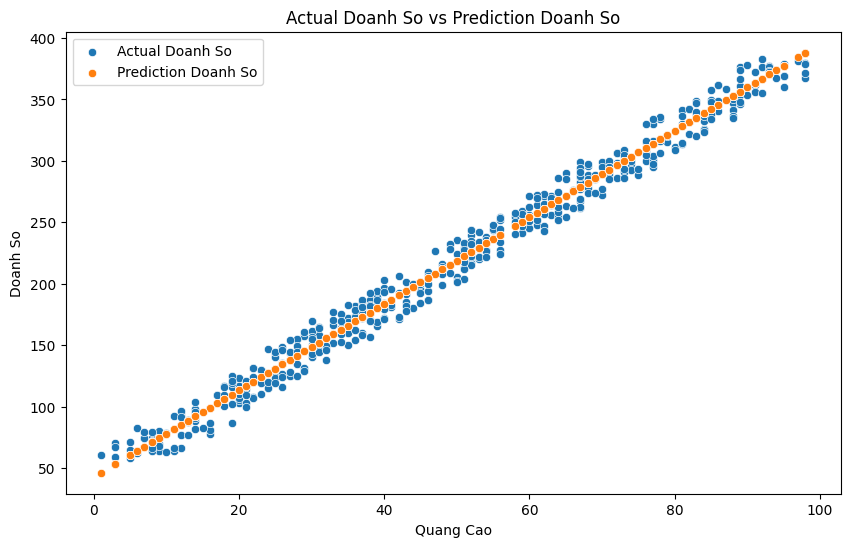

In [82]:
import matplotlib.pyplot as plt
import seaborn as sbn

plt.figure(figsize=(10, 6))
plt.title('Actual Doanh So vs Prediction Doanh So')
sbn.scatterplot(x=x_quang_cao_test, y=y_doanh_so_test, label='Actual Doanh So')
sbn.scatterplot(x=x_quang_cao_test, y=y_pred, label='Prediction Doanh So')
plt.xlabel('Quang Cao')
plt.ylabel('Doanh So')
plt.legend()
plt.show()

In [84]:
print("Coefficient (a):", linearModel.coef_[0])
print("Intercept(b):", linearModel.intercept_)

Coefficient (a): 3.5219106687772066
Intercept(b): 42.8584401474391


In [85]:
print('R-square of qcModel:', r2_score(y_doanh_so_test, y_pred))
print('MSE of qcModel:', mean_squared_error(y_doanh_so_test, y_pred))

R-square of qcModel: 0.9863987385668086
MSE of qcModel: 107.55864520190353


======Multiple Features Linear Regression

In [ ]:
multipleLinearRegresDf = pd.read_csv('data_multiple_reg.csv')

,TT,Quang_Cao,PR,Online,KOL,Doanh_So
0,0,Low,1.034766,4.297423,Micro,80.261284
1,1,Low,5.340160,0.744989,Mega,92.574904
2,2,High,21.918056,0.004401,Micro,297.250108
3,3,Medium-High,20.288928,0.688838,Mega,220.102176
4,4,High,30.048338,7.365014,Nano,298.960377
...,...,...,...,...,...,...
567,567,Medium-Low,16.461286,2.883458,Micro,216.521266
568,568,High,28.512999,6.675807,Mega,322.626731
569,569,Medium-Low,9.573457,4.508572,Nano,170.416851
570,570,Medium-High,23.390934,6.925610,Macro,234.326830


In [95]:
x = multipleLinearRegresDf[['PR', 'Online']]
y = multipleLinearRegresDf['Doanh_So']

In [94]:
print(x)
print(y)

            PR    Online
0     1.034766  4.297423
1     5.340160  0.744989
2    21.918056  0.004401
3    20.288928  0.688838
4    30.048338  7.365014
..         ...       ...
567  16.461286  2.883458
568  28.512999  6.675807
569   9.573457  4.508572
570  23.390934  6.925610
571  12.154572  2.826728

[572 rows x 2 columns]
0       80.261284
1       92.574904
2      297.250108
3      220.102176
4      298.960377
          ...    
567    216.521266
568    322.626731
569    170.416851
570    234.326830
571    160.773151
Name: Doanh_So, Length: 572, dtype: float64


In [96]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [97]:
mulLinearRegresModel = LinearRegression()
mulLinearRegresModel.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [98]:
coefs = mulLinearRegresModel.coef_
intercept = mulLinearRegresModel.intercept_

print(f'Coefficients: {coefs}, Intercept: {intercept}')

Coefficients: [7.79729743 1.53478793], Intercept: 72.48797770580825


In [100]:
y_mulLR_Pred = mulLinearRegresModel.predict(x_test)
y_mulLR_Pred

array([176.50733186, 198.68360393, 228.39753013, 143.72248118,
       286.99004774, 155.63141426, 193.64677082, 202.09275816,
       215.82717988, 273.86497208, 276.1381291 , 157.6654171 ,
       321.75753558, 219.42602715, 256.48882395, 213.66811165,
       123.50956636, 290.66614054, 217.83869115, 189.8464402 ,
       313.84741432, 162.14838856, 210.52288549, 159.33763663,
       182.77755892,  77.26162229, 164.74022131, 230.970155  ,
       146.88580046, 233.72352665, 321.29815439, 265.50339357,
       234.29972847, 138.8554318 , 171.52710865, 175.17922911,
       230.04615508, 236.13886426, 200.78120462, 105.09034709,
       251.06212236, 185.79722982, 254.29596406, 225.76210624,
        94.45873539, 197.31654967,  93.51266963, 337.72591513,
       232.7550766 , 299.20490856, 184.54996031, 164.05910177,
        82.07361593, 271.08319411, 218.92331862, 255.33667524,
       244.41363801, 263.12417788, 230.5973927 , 284.67596305,
       232.23105675, 243.39633179, 205.26701535, 305.25

In [101]:
print('R-square of qcModel:', r2_score(y_test, y_mulLR_Pred))
print('MSE of qcModel:', mean_squared_error(y_test, y_mulLR_Pred))


R-square of qcModel: 0.6218100908639569
MSE of qcModel: 2961.9895308759837


In [104]:
multipleLinearRegresDf['Quang_Cao']

0              Low
1              Low
2             High
3      Medium-High
4             High
          ...     
567     Medium-Low
568           High
569     Medium-Low
570    Medium-High
571            Low
Name: Quang_Cao, Length: 572, dtype: object

In [102]:
qc_encode = pd.get_dummies(multipleLinearRegresDf['Quang_Cao'])
qc_encode

,High,Low,Medium-High,Medium-Low
0,False,True,False,False
1,False,True,False,False
2,True,False,False,False
3,False,False,True,False
4,True,False,False,False
...,...,...,...,...
567,False,False,False,True
568,True,False,False,False
569,False,False,False,True
570,False,False,True,False


In [106]:
x = pd.concat([qc_encode, multipleLinearRegresDf[['PR', 'Online']]], axis=1)
x



,High,Low,Medium-High,Medium-Low,PR,Online
0,False,True,False,False,1.034766,4.297423
1,False,True,False,False,5.340160,0.744989
2,True,False,False,False,21.918056,0.004401
3,False,False,True,False,20.288928,0.688838
4,True,False,False,False,30.048338,7.365014
...,...,...,...,...,...,...
567,False,False,False,True,16.461286,2.883458
568,True,False,False,False,28.512999,6.675807
569,False,False,False,True,9.573457,4.508572
570,False,False,True,False,23.390934,6.925610


In [107]:
y = multipleLinearRegresDf['Doanh_So']
y

0       80.261284
1       92.574904
2      297.250108
3      220.102176
4      298.960377
          ...    
567    216.521266
568    322.626731
569    170.416851
570    234.326830
571    160.773151
Name: Doanh_So, Length: 572, dtype: float64

In [110]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

mulLinearRegresModel.fit(x_train, y_train)

y_mulLR_Pred = mulLinearRegresModel.predict(x_test)

print('R-square of qcModel:', r2_score(y_test, y_mulLR_Pred))
print('MSE of qcModel:', mean_squared_error(y_test, y_mulLR_Pred))

R-square of qcModel: 0.9201077693745625
MSE of qcModel: 625.7172520849864


=====Logistic Regression

In [17]:
dataLRDf = pd.read_csv('data_logistic_reg.csv')
dataLRDf

,TT,Danh_Gia,Chat_Luong_Tai_Xe,Thoi_Gian_vs_Du_Kien
0,0,satisfied,6,-11.56250
1,1,satisfied,1,-12.34375
2,2,satisfied,1,-11.56250
3,3,satisfied,6,-11.56250
4,4,satisfied,3,-11.56250
...,...,...,...,...
129875,129875,satisfied,6,-11.56250
129876,129876,dissatisfied,1,-11.87500
129877,129877,dissatisfied,2,-10.31250
129878,129878,dissatisfied,2,-9.68750


In [18]:
dataLRDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   TT                    129880 non-null  int64  
 1   Danh_Gia              129880 non-null  object 
 2   Chat_Luong_Tai_Xe     129880 non-null  int64  
 3   Thoi_Gian_vs_Du_Kien  129487 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 4.0+ MB


In [19]:
dataLRDf.dropna(inplace=True)


In [20]:
dataLRDf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129487 entries, 0 to 129879
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   TT                    129487 non-null  int64  
 1   Danh_Gia              129487 non-null  object 
 2   Chat_Luong_Tai_Xe     129487 non-null  int64  
 3   Thoi_Gian_vs_Du_Kien  129487 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 4.9+ MB


In [29]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


encoder = LabelEncoder()

dataLRDf['Danh_Gia'] = encoder.fit_transform(dataLRDf['Danh_Gia'])
dataLRDf

,TT,Danh_Gia,Chat_Luong_Tai_Xe,Thoi_Gian_vs_Du_Kien
0,0,1,6,-11.56250
1,1,1,1,-12.34375
2,2,1,1,-11.56250
3,3,1,6,-11.56250
4,4,1,3,-11.56250
...,...,...,...,...
129875,129875,1,6,-11.56250
129876,129876,0,1,-11.87500
129877,129877,0,2,-10.31250
129878,129878,0,2,-9.68750


In [30]:
x_lr = dataLRDf[['Chat_Luong_Tai_Xe', 'Thoi_Gian_vs_Du_Kien']]
y_lr = dataLRDf['Danh_Gia']

In [31]:
x_lr_train, x_lr_test, y_lr_train, y_lr_test = train_test_split(x_lr, y_lr, test_size=0.1, random_state=42)


In [32]:
lrModel = LogisticRegression()
lrModel.fit(x_lr_train, y_lr_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [36]:
y_lr_pred = lrModel.predict(x_lr_test)
accuracyScore = accuracy_score(y_lr_test, y_lr_pred)
precisioncore = precision_score(y_lr_test, y_lr_pred)
recallScore = recall_score(y_lr_test, y_lr_pred)
f1Score = f1_score(y_lr_test, y_lr_pred)

print(f'Accuracy Score: {accuracyScore}')
print(f'Precision Score: {precisioncore}')
print(f'Recall Score: {recallScore}')
print(f'F1 Score: {f1Score}')

Accuracy Score: 0.80206965788864
Precision Score: 0.8148984198645598
Recall Score: 0.8219723922015084
F1 Score: 0.818420120439249
